In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Sample Data

In [3]:
df = pd.read_csv('state_population_murder.csv')
df

,State,Population,Murder_rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,5.8,CO
6,Connecticut,3574097,2.8,CT
7,Delaware,897934,2.4,DE


Analyzing the Population

Mean

In [4]:
print("Mean of Population: ", df['Population'].mean())

Mean of Population:  7694135.625


10% Trimmed Mean

In [5]:
# 10% Trimmed Mean

# 1- Get the population series and sort it
pop = df['Population']
pop = pop.sort_values()
 
# get the number of rows to trim
n = len(pop)
p = int(0.1 * n)

# slice the population
pop = pop[p : n - p]
print("Trimmed Population Mean (10%): ", pop.mean())

Trimmed Population Mean (10%):  7694135.625


Median

In [6]:
print("Median of Population: ", df['Population'].median())

Median of Population:  4176916.5


Standard Deviation

In [7]:
print("Standard Deviation of Population is: ", df['Population'].std())

Standard Deviation of Population is:  12105745.29585633


IQR

In [8]:
print("IQR of Population is: ", df['Population'].quantile(0.75) - df['Population'].quantile(0.25))

IQR of Population is:  2958479.25


Boxplot

<Axes: >

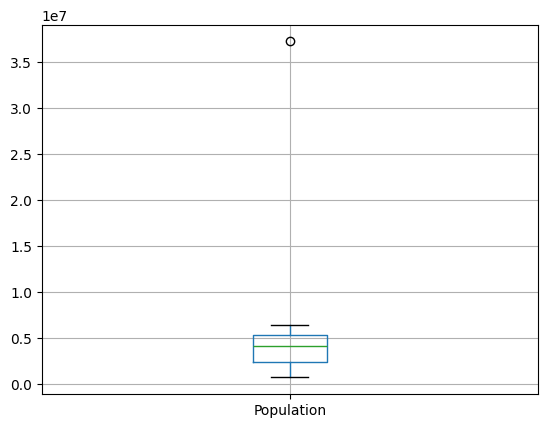

In [9]:
df.boxplot(column = 'Population')

Frequency Table

In [10]:
# Create 10 population bins
binned_population = pd.cut(df['Population'], 10)

# Frequency table
freq_table = binned_population.value_counts().sort_index()
freq_table

Population
(673687.275, 4364603.5]     4
(4364603.5, 8018976.0]      3
(8018976.0, 11673348.5]     0
(11673348.5, 15327721.0]    0
(15327721.0, 18982093.5]    0
(18982093.5, 22636466.0]    0
(22636466.0, 26290838.5]    0
(26290838.5, 29945211.0]    0
(29945211.0, 33599583.5]    0
(33599583.5, 37253956.0]    1
Name: count, dtype: int64

In [11]:
states_per_bin = df.groupby(binned_population)['State'].apply(list)
states_per_bin

C:\Users\USER\AppData\Local\Temp\ipykernel_5420\2037594834.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  states_per_bin = df.groupby(binned_population)['State'].apply(list)


Population
(673687.275, 4364603.5]     [Alaska, Arkansas, Connecticut, Delaware]
(4364603.5, 8018976.0]                   [Alabama, Arizona, Colorado]
(8018976.0, 11673348.5]                                            []
(11673348.5, 15327721.0]                                           []
(15327721.0, 18982093.5]                                           []
(18982093.5, 22636466.0]                                           []
(22636466.0, 26290838.5]                                           []
(26290838.5, 29945211.0]                                           []
(29945211.0, 33599583.5]                                           []
(33599583.5, 37253956.0]                                 [California]
Name: State, dtype: object

Plot Histogram

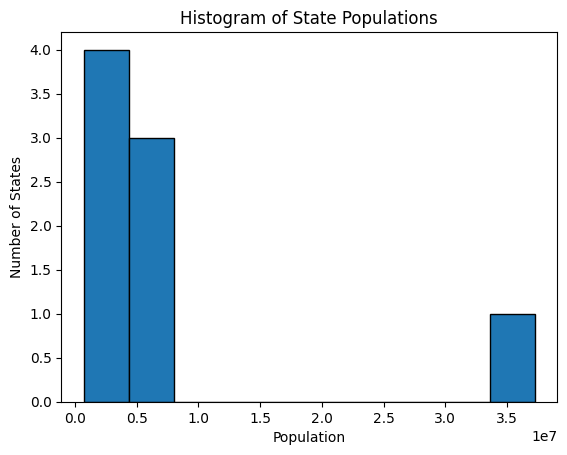

In [12]:
# Plot histogram
pop = np.array(df['Population'])
plt.hist(pop, bins=10, edgecolor='black')
plt.title("Histogram of State Populations")
plt.xlabel("Population")
plt.ylabel("Number of States")
plt.show()

Scatter Plot

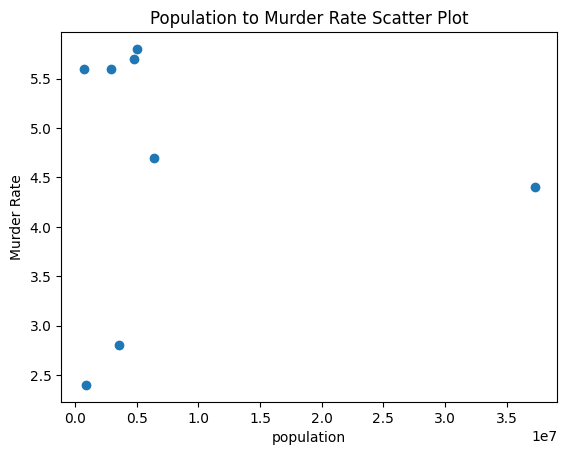

In [19]:
pop = np.array(df['Population'])
murder_rate = np.array(df['Murder_rate'])

plt.scatter(pop, murder_rate)
plt.title("Population to Murder Rate Scatter Plot")
plt.xlabel("population")
plt.ylabel("Murder Rate")

plt.show()

Analysing Murder Rate

Mean

In [13]:
print("The Mean Murder Rate is: ", df['Murder_rate'].mean())

The Mean Murder Rate is:  4.625


10% Trimmed Median

In [14]:
# Sort Crime Rates
murder_rate = df['Murder_rate'].sort_values()

# Get the number of rows to trim
n = len(murder_rate)
p = int(0.1 * n)

# Trim the df
murder_rate = murder_rate[p : n - p ]

# get the trimmed mean
print("Trimmed Murder Rate Mean (10%): ", murder_rate.mean())

Trimmed Murder Rate Mean (10%):  4.625


Weighted Murder Rate

In [15]:
weighted_mean_murder = np.average(df['Murder_rate'], weights=df['Population'])
print(f"Weighted mean of Murder Rate (by population): {weighted_mean_murder:.4f}")

Weighted mean of Murder Rate (by population): 4.5951
